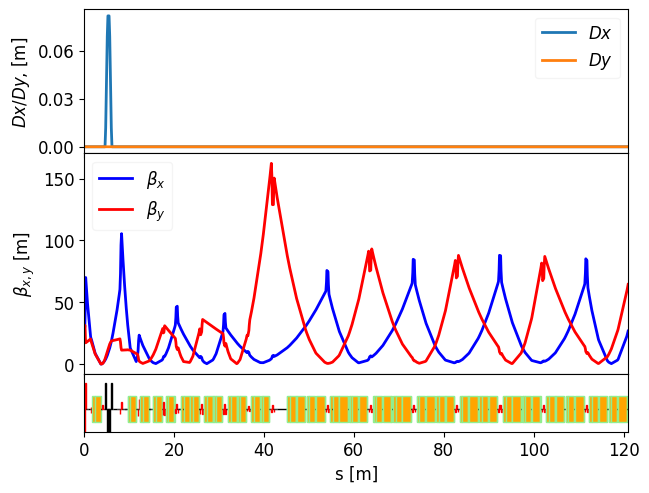

In [ ]:
from ocelot import *
from ocelot.cpbd.elements import *
from ocelot.gui.accelerator import *
from ocelot.cpbd.track import track_debug
import matplotlib.pyplot as plt


from linac import *


lat = MagneticLattice()



##### PA1RFGUN #####
AX =-21.12   
BX =24.36 
AY =-21.16     
BY =24.42      
EMITX =1.2023504614117648e-06
EMITY =1.2023504614117648e-06 
DP =.01
##### PA1RFGUN #####

energy = 0.0091 # GeV  #why?
tw0 = Twiss()
tw0.alpha_x = AX
tw0.beta_x = BX

tw0.alpha_y = AY
tw0.beta_y = BY
tw0.E = energy
tw0.emit_xn = EMITX 
tw0.emit_yn = EMITY
tw0.emit_x = EMITX   / energy * 0.511e-3
tw0.emit_y = EMITY / energy * 0.511e-3

tws = twiss(lat,tw0)

plot_opt_func(lat, tws,legend=False, grid=False, top_plot=['Dx','Dy'])

In [21]:
def gauss_from_twiss_vec(emit, beta, alpha, size=1):
    phi = 2 * np.pi * np.random.rand(size)
    u = np.random.rand(size)
    a = np.sqrt(-2 * np.log(1 - u) * emit)
    x = a * np.sqrt(beta) * np.cos(phi)
    xp = -a / np.sqrt(beta) * (np.sin(phi) + alpha * np.cos(phi))
    return x, xp

nparticles = 100000
p_array = ParticleArray(n=nparticles)

# sigma_tau = 6.7e-3  # (bunch length in time)
# sigma_p = 5.e-4     # relative momentum spread (Δp/p)  

sigma_tau = 2e-3  # (bunch length in time)
sigma_p = 0.1     # relative momentum spread (Δp/p)  

p_array.E = energy  # GeV

# Longitudinal
p_array.rparticles[4] = np.random.randn(nparticles) * sigma_tau
p_array.rparticles[5] = np.random.randn(nparticles) * sigma_p

# Transverse: vectorized sampling from Twiss parameters
x, xp = gauss_from_twiss_vec(tw0.emit_x, tw0.beta_x, tw0.alpha_x, size=nparticles)
y, yp = gauss_from_twiss_vec(tw0.emit_y, tw0.beta_y, tw0.alpha_y, size=nparticles)

p_array.rparticles[0] = x
p_array.rparticles[1] = xp
p_array.rparticles[2] = y
p_array.rparticles[3] = yp

# Charge distribution
charge = 4.0e-9  # nC
p_array.q_array = np.ones(nparticles) * (charge / nparticles)




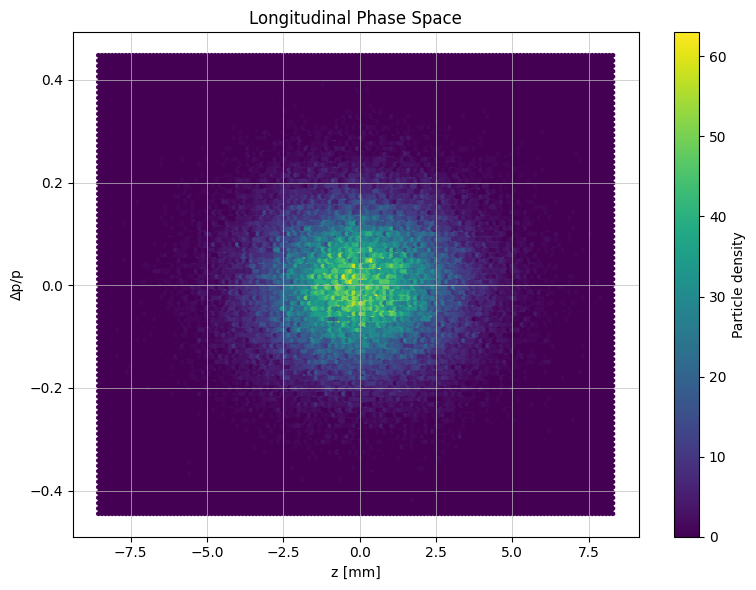

In [22]:
import matplotlib.pyplot as plt

# Longitudinal phase space: z vs. Δp/p
z = p_array.rparticles[4]   # in meters
dp_p = p_array.rparticles[5]  # unitless

plt.figure(figsize=(8,6))
plt.hexbin(z * 1e3, dp_p, gridsize=150, cmap='viridis')  # convert z to mm for better readability
plt.colorbar(label='Particle density')
plt.xlabel("z [mm]")
plt.ylabel("Δp/p")
plt.title("Longitudinal Phase Space")
plt.grid(True)
plt.tight_layout()
plt.show()


s = 0.100 m, σ_τ = 2.008e-03 s
z = 0.1 / 121.0150314000005. Applied: HookProcesss = 0.200 m, σ_τ = 2.008e-03 s
z = 0.2 / 121.0150314000005. Applied: HookProcesss = 0.300 m, σ_τ = 2.010e-03 s
z = 0.30000000000000004 / 121.0150314000005. Applied: HookProcesss = 0.400 m, σ_τ = 2.011e-03 s
z = 0.4 / 121.0150314000005. Applied: HookProcesss = 0.500 m, σ_τ = 2.014e-03 s
z = 0.5 / 121.0150314000005. Applied: HookProcesss = 0.600 m, σ_τ = 2.016e-03 s
z = 0.6 / 121.0150314000005. Applied: HookProcesss = 0.700 m, σ_τ = 2.020e-03 s
z = 0.7 / 121.0150314000005. Applied: HookProcesss = 0.800 m, σ_τ = 2.023e-03 s
z = 0.7999999999999999 / 121.0150314000005. Applied: HookProcesss = 0.900 m, σ_τ = 2.028e-03 s
z = 0.8999999999999999 / 121.0150314000005. Applied: HookProcesss = 1.000 m, σ_τ = 2.032e-03 s
z = 0.9999999999999999 / 121.0150314000005. Applied: HookProcesss = 1.100 m, σ_τ = 2.038e-03 s
z = 1.0999999999999999 / 121.0150314000005. Applied: HookProcesss = 1.200 m, σ_τ = 2.043e-03 s
z = 1.2 / 121

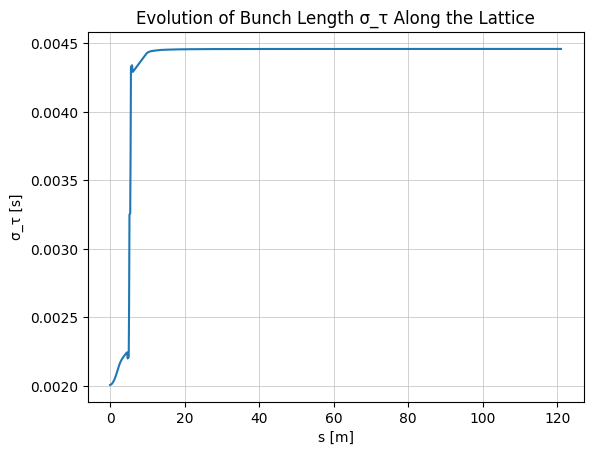

In [24]:
import time
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt
from ocelot.cpbd.physics_proc import PhysProc

# Create the Navigator
navi = Navigator(lat)
navi.unit_step = 0.1  # high-resolution steps

# CSR example (optional)
# csr = CSR(n_bin=500, m_bin=5, sigma_min=.2e-6)
# navi.add_physics_proc(csr, csrm1_start, csrm1_end)

# Define the hook as a physics process
class HookProcess(PhysProc):
    def __init__(self, sigma_tau_list):
        super().__init__()
        self.sigma_tau_list = sigma_tau_list

    def apply(self, p_array, step_size):
        sigma_tau = np.std(p_array.rparticles[4])
        self.sigma_tau_list.append(sigma_tau)
        print(f"s = {self.z0:.3f} m, σ_τ = {sigma_tau:.3e} s")

# Attach the custom hook process
sigma_tau_list = []
hook_proc = HookProcess(sigma_tau_list)
navi.add_physics_proc(hook_proc, lat.sequence[0], lat.sequence[-1])

# Track
p_array_t = deepcopy(p_array)
start = time.time()
tws_track, p_array_t = track(lat, p_array_t, navi)
print("\n time exec:", time.time() - start, "sec")

# Plot
print("sigma_tau_list length:", len(sigma_tau_list))
print("lat.totalLen:", lat.totalLen)

s_axis = np.linspace(0, lat.totalLen, len(sigma_tau_list))
plt.plot(s_axis, sigma_tau_list)
plt.xlabel("s [m]")
plt.ylabel("σ_τ [s]")
plt.title("Evolution of Bunch Length σ_τ Along the Lattice")
plt.grid(True)
plt.show()






In [25]:
sigma_tau = np.std(p_array.rparticles[4])
print("σ_τ before tracking:", sigma_tau, "s")

sigma_tau = np.std(p_array_t.rparticles[4])
print("σ_τ after tracking:", sigma_tau, "s")

σ_τ before tracking: 0.0020072399845559572 s
σ_τ after tracking: 0.004459522520061569 s


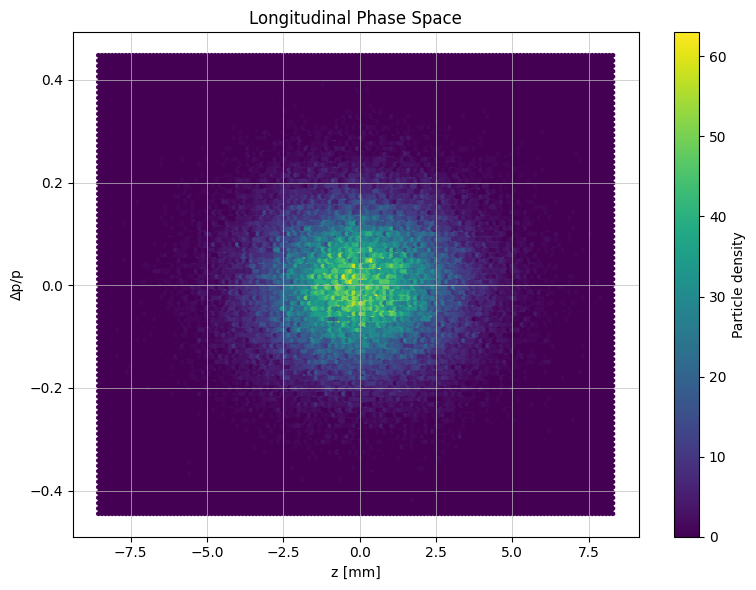

In [26]:
#PLOT LONGITUDINAL PHASE SPACE 
import matplotlib.pyplot as plt

# Longitudinal phase space: z vs. Δp/p
z = p_array.rparticles[4]   # in meters
dp_p = p_array.rparticles[5]  # unitless

plt.figure(figsize=(8,6))
plt.hexbin(z * 1e3, dp_p, gridsize=150, cmap='viridis')  # convert z to mm for better readability
plt.colorbar(label='Particle density')
plt.xlabel("z [mm]")
plt.ylabel("Δp/p")
plt.title("Longitudinal Phase Space")
plt.grid(True)
plt.tight_layout()
plt.show()


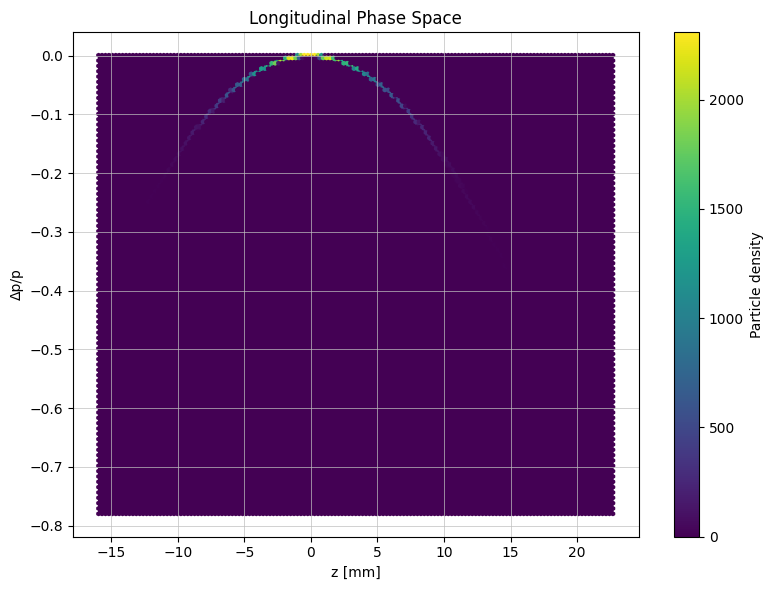

In [27]:
import matplotlib.pyplot as plt

# Longitudinal phase space: z vs. Δp/p
z = p_array_t.rparticles[4]   # in meters
dp_p = p_array_t.rparticles[5]  # unitless

plt.figure(figsize=(8,6))
plt.hexbin(z * 1e3, dp_p, gridsize=150, cmap='viridis')  # convert z to mm for better readability
plt.colorbar(label='Particle density')
plt.xlabel("z [mm]")
plt.ylabel("Δp/p")
plt.title("Longitudinal Phase Space")
plt.grid(True)
plt.tight_layout()
plt.show()


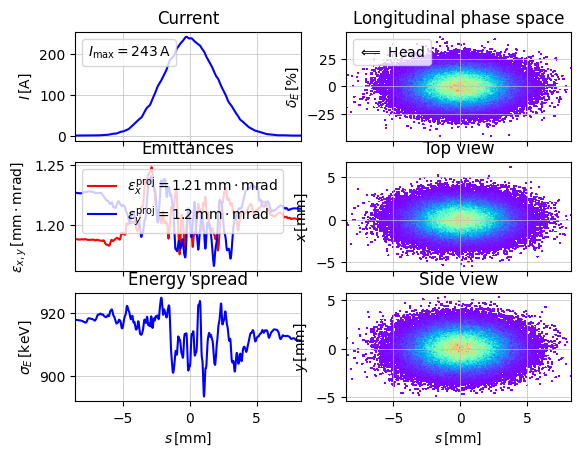

In [28]:
show_e_beam(p_array)

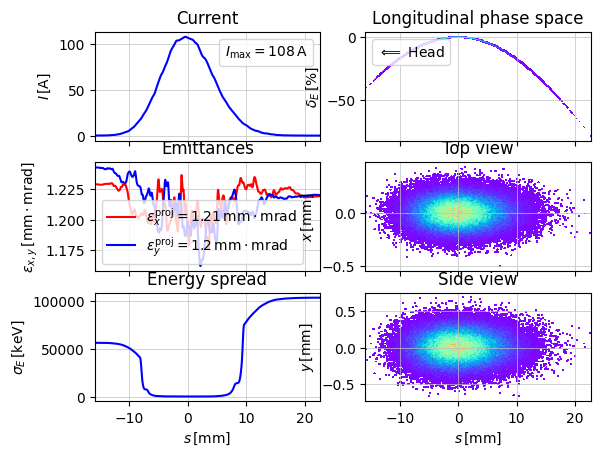

In [29]:
show_e_beam(p_array_t)

In [30]:
import matplotlib.pyplot as plt
import numpy as np

def plot_energy_vs_position(tws_track):
    """
    Plot energy E as a function of position s from a list of Twiss-like objects.

    Parameters:
    tws_track (list): List of objects with attributes 's' (position) and 'E' (energy).
    """
    s = np.array([tw.s for tw in tws_track])
    E = np.array([tw.E for tw in tws_track])

    plt.figure(figsize=(10, 6))
    plt.plot(s, E, linewidth=2, marker='o', markersize=4)

    plt.title("Energy vs Position", fontsize=16)
    plt.xlabel("s (m)", fontsize=14)
    plt.ylabel("E (GeV)", fontsize=14)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.tick_params(axis='both', labelsize=12)
    plt.tight_layout()
    plt.show()



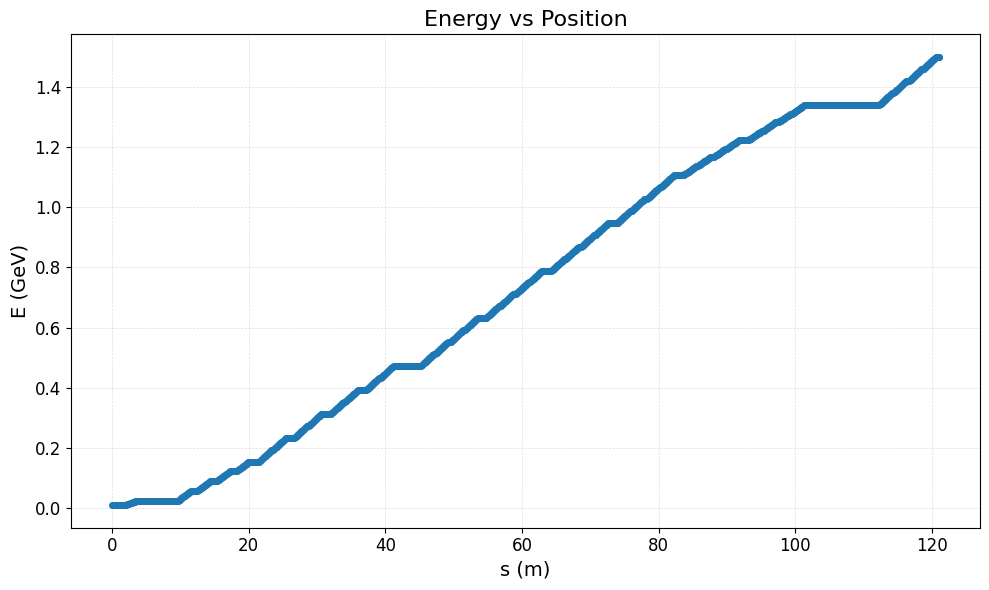

In [31]:
plot_energy_vs_position(tws_track)
